<a href="https://colab.research.google.com/github/janani26121992/AI-Projects/blob/main/Text_Classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Text Classification project

# **Project** Objective: Build a text classification model that predicts the intent of customer review whether the review is positive or negative.
Data Gathering**

In [1]:
path = r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/Restaurant_Reviews.tsv'
import pandas as pd
df= pd.read_csv(path,sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [3]:
df['Review'].head()

,Review
0,Wow... Loved this place.
1,Crust is not good.
2,Not tasty and the texture was just nasty.
3,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...


In [4]:
s1 = df['Review'][0]
s1.lower()

'wow... loved this place.'

In [5]:
import re
s1=s1.lower()
pattern = r"[^a-z ]"
s1 = re.sub(pattern,"",s1)
s1

'wow loved this place'

In [6]:
def preprocess(text):
  text =text.lower()
  pattern = r"[^a-z ]"
  text = re.sub(pattern,"",text)
  return text

In [7]:
df['Review_Preprocessed'] = df['Review'].apply(preprocess)


In [8]:
df['Review_Preprocessed'].head(10)

,Review_Preprocessed
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...
5,now i am getting angry and i want my damn pho
6,honeslty it didnt taste that fresh
7,the potatoes were like rubber and you could te...
8,the fries were great too
9,a great touch


In [9]:
df.head()

,Review,Liked,Review_Preprocessed
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good.,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...


# **Separate X and Y features**
# X: Review_Preprocessed

## **Y : Liked**

In [10]:
x = df['Review_Preprocessed']
y = df['Liked']

In [11]:
x.head()

,Review_Preprocessed
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...


In [12]:
y.head()

,Liked
0,1
1,0
2,0
3,1
4,1


# **Vectorization**

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
xpre = tfidf.fit_transform(x).toarray()

In [15]:
xpre

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# **Split the data into training and testing**

In [16]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(xpre,y,train_size=0.85,random_state=21)


# **Model Building**
# While building and tuning the model, you can tweak below parameters and see if there is significant change in the model predictions.
# **Awalys restart kernel and run all cells**

while splitting the data into training and testing,
you can modify the size

you can increase more neurons to the hidden layers

you can add more layers to the architechture

you can update the patience levels in ReduceLR

you can update the batch size

In [17]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import ReduceLROnPlateau

# Intialize the model
model = Sequential()

# Add the layers
model.add(Input(shape=(xtrain.shape[1],)))

# Add the hidden layer
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(rate=0.3))

# Add the hidden layer
model.add(Dense(units=32,activation='relu'))
model.add(Dropout(rate=0.2))

# Add the hidden layer
model.add(Dense(units=16,activation='relu'))
model.add(Dropout(rate=0.1))

# Add the Output layer
model.add(Dense(units=1,activation='sigmoid'))

In [18]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
learning_rate = ReduceLROnPlateau(monitor='val_loss',patience=2,min_lr=0.0001,factor=0.85,verbose=1)

In [19]:
nn = model.fit(xtrain,ytrain,validation_split=0.2,epochs=15,callbacks=[learning_rate],batch_size=8)

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5250 - loss: 0.6908 - val_accuracy: 0.5588 - val_loss: 0.6855 - learning_rate: 0.0010
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7632 - loss: 0.6201 - val_accuracy: 0.6000 - val_loss: 0.6135 - learning_rate: 0.0010
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9029 - loss: 0.3393 - val_accuracy: 0.8118 - val_loss: 0.4244 - learning_rate: 0.0010
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9706 - loss: 0.1244 - val_accuracy: 0.7647 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 5/15
83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0501
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0008500000403728336.
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9926 - loss: 0.0421 - val_accuracy: 0.7941 - val_loss: 0.5450 - learning_rate: 0.0010
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9971 - loss: 0.0219 - val_accuracy: 

# **Learning Curve**

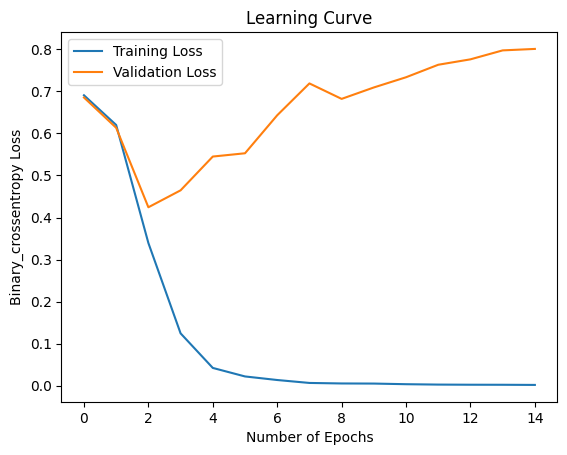

In [20]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Binary_crossentropy Loss")
plt.legend()
plt.show()

In [22]:
model.evaluate(xtrain,ytrain)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9588 - loss: 0.1604


[0.16043339669704437, 0.9588235020637512]

In [23]:
model.evaluate(xtest,ytest)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.8467 - loss: 0.5762


[0.576165497303009, 0.846666693687439]

# Accuracy score is 80% . We can consider this model as final model

# **Out of sample predictions**

In [24]:
def predict(text):
  review_updated = preprocess(text)
  review_pre = tfidf.transform([review_updated]).toarray()
  probs = model.predict(review_pre,verbose=0)
  if probs>0.5:
    print("Positive Review")
  else:
    print("Negative Review")

In [29]:
review = "Food taste is not so good..!!"

In [30]:
predict(review)

Negative Review


In [32]:
model.save('text-generation-app.keras')